# Lab 1 - Linear Regression


## Step 1-2: Import Libraries

In [11]:
import numpy as np
import pandas as pd

## Step 3: Read the Data

In [12]:
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/Foto/dataset.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 4: Understanding the Data

In [13]:
data.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\r\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\r\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\r\nCobbborough,...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\r\nPort Jason, OH 22070-...",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\r\nPort Jacobville, PR...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [14]:
data.shape

(500, 8)

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [16]:
data.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


## Step 5: Data Visualization

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

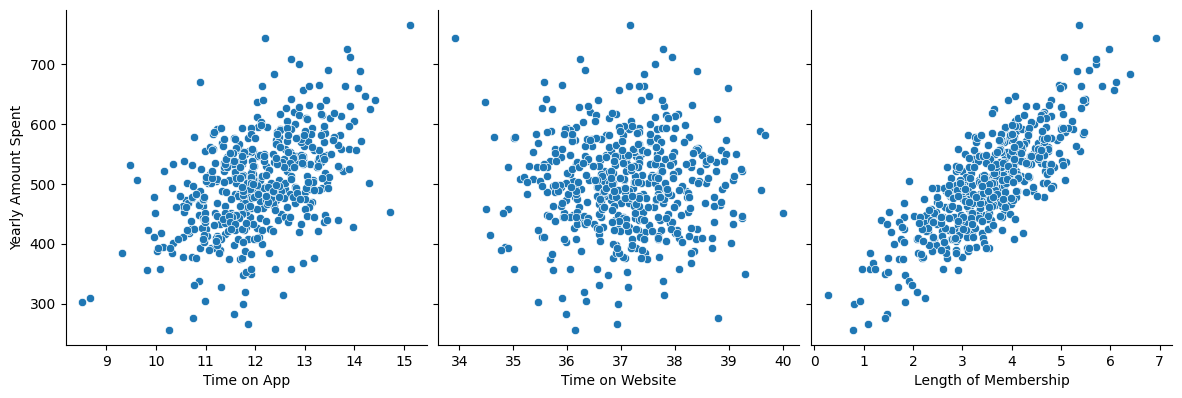

In [18]:
sns.pairplot(data, x_vars=['Time on App', 'Time on Website', 'Length of Membership'],
             y_vars='Yearly Amount Spent', height=4, aspect=1, kind='scatter')
plt.show()

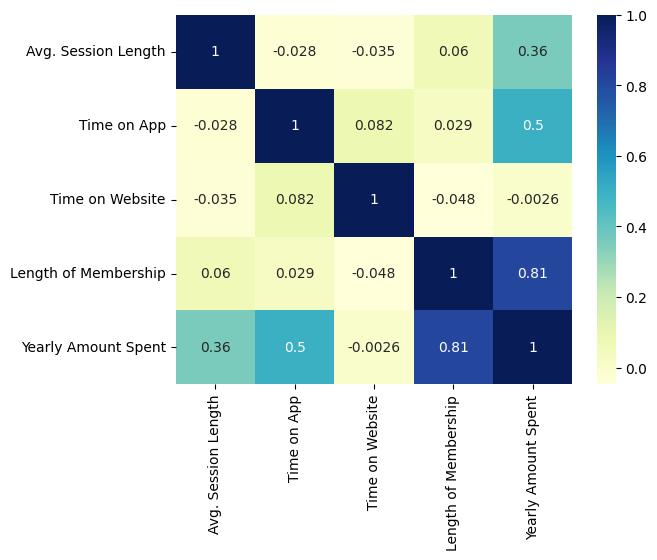

In [19]:
sns.heatmap(data.corr(numeric_only=True), cmap='YlGnBu', annot=True)
plt.show()

## Step 6: Linear Regression

In [20]:
X = data['Length of Membership']
y = data['Yearly Amount Spent']

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=100)
print(X_train.shape, X_test.shape)

(350,) (150,)


In [22]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
lr = sm.OLS(y_train, X_train_sm).fit()
lr.params

,0
const,265.248299
Length of Membership,66.301522


In [23]:
print(lr.summary())

                             OLS Regression Results                            
Dep. Variable:     Yearly Amount Spent   R-squared:                       0.669
Model:                             OLS   Adj. R-squared:                  0.668
Method:                  Least Squares   F-statistic:                     702.9
Date:                 Tue, 29 Sep 2026   Prob (F-statistic):           1.59e-85
Time:                         13:31:00   Log-Likelihood:                -1841.3
No. Observations:                  350   AIC:                             3687.
Df Residuals:                      348   BIC:                             3694.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 

y = 265.2483 + 66.3015 * x


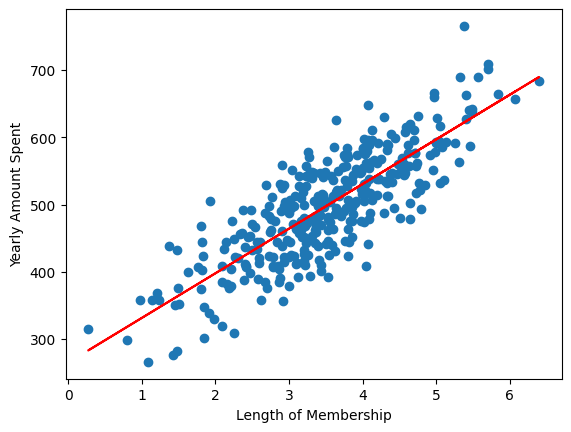

In [25]:
intercept, slope = lr.params['const'], lr.params['Length of Membership']
print(f'y = {intercept:.4f} + {slope:.4f} * x')

plt.scatter(X_train, y_train)
plt.plot(X_train, intercept + slope * X_train, 'r')
plt.xlabel('Length of Membership'); plt.ylabel('Yearly Amount Spent')
plt.show()

## Step 7: Residual Analysis

In [26]:
y_train_pred = lr.predict(X_train_sm)
res = y_train - y_train_pred

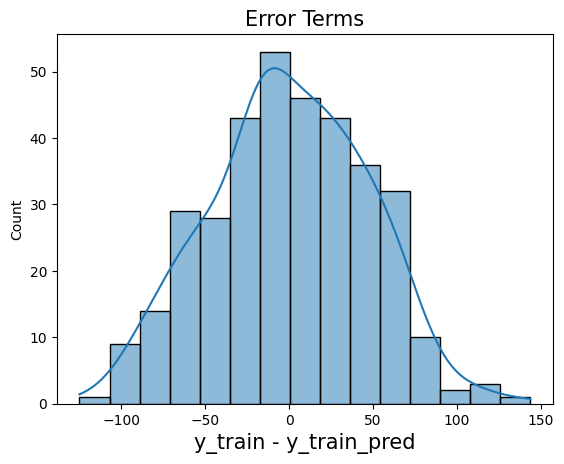

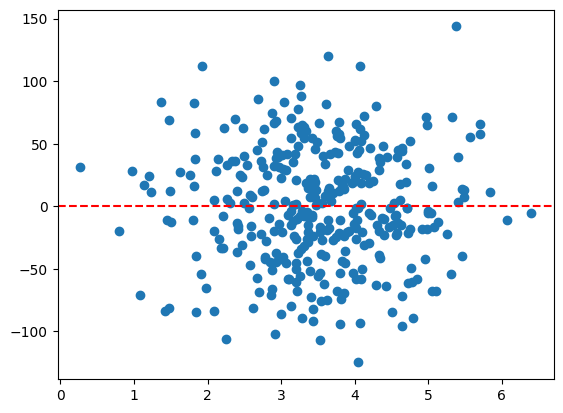

In [27]:
plt.figure()
sns.histplot(res, bins=15, kde=True)
plt.title('Error Terms', fontsize=15)
plt.xlabel('y_train - y_train_pred', fontsize=15)
plt.show()

plt.scatter(X_train, res)
plt.axhline(0, color='r', linestyle='--')
plt.show()

## Step 8: Prediction on Test Data and Evaluation

In [28]:
X_test_sm = sm.add_constant(X_test)
y_test_pred = lr.predict(X_test_sm)

In [29]:
from sklearn.metrics import r2_score
r_squared = r2_score(y_test, y_test_pred)
print('R-squared (test):', r_squared)

R-squared (test): 0.611948913768747


## Step 9: Visualization of Results

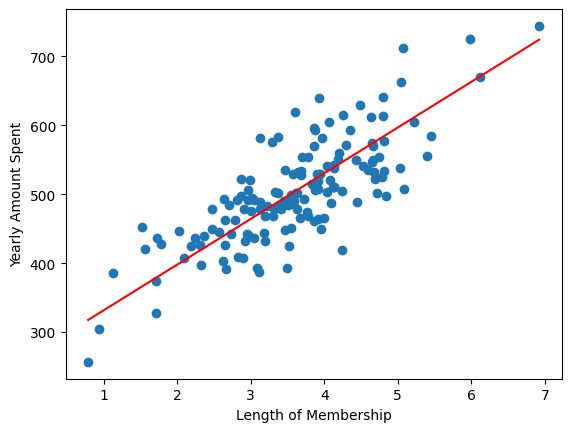

In [30]:
plt.scatter(X_test, y_test)
plt.plot(X_test.sort_values(), y_test_pred.loc[X_test.sort_values().index], 'r')
plt.xlabel('Length of Membership'); plt.ylabel('Yearly Amount Spent')
plt.show()